# Unidad 2: Aprendizaje Automático
## Normalización vs Estandarización
### Inteligencia Artificial — Lic. en Sistemas — FCAD/UNER

---

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/CristianPacifico/ia-ls-fcad-uner/blob/main/notebooks/ml/supervised/26_Normalization_vs_Standardization.ipynb)

## 🎯 ¿Qué vamos a aprender?

**Normalización** y **Estandarización** son las dos técnicas de escalado de features más usadas en Machine Learning. Aunque ambas transforman los datos para que sean comparables, lo hacen de formas distintas y aplican mejor en contextos diferentes.

Al finalizar, vas a poder:
- ✅ Explicar la diferencia matemática entre normalización y estandarización
- ✅ Visualizar el efecto de cada técnica sobre distribuciones reales
- ✅ Comprender el impacto de los **outliers** en cada técnica
- ✅ Elegir la técnica correcta para KNN, SVM y regresión logística
- ✅ Demostrar empíricamente cómo el escalado mejora el rendimiento de los modelos

---

## 🧠 Marco Teórico

### ¿Por qué escalar las features?

Muchos algoritmos de ML calculan **distancias** o usan **gradientes** entre features. Si una feature tiene valores en miles (ej: ingreso anual) y otra en decenas (ej: edad), la primera dominará artificialmente los cálculos:

```
Sin escalar:
  Ingreso: [20000, 35000, 80000]   ← rango de 60.000
  Edad:    [    25,    40,    55]   ← rango de 30

  → El ingreso domina cualquier cálculo de distancia euclidiana
  → La edad queda opacada aunque sea igual de informativa

Con escalado:
  Ingreso: [0.00, 0.25, 1.00]
  Edad:    [0.00, 0.50, 1.00]
  → Ambas contribuyen por igual
```

---

### 📐 Normalización (MinMax Scaling)

Reescala cada feature a un rango fijo, generalmente **[0, 1]**:

$$x_{norm} = \frac{x - x_{min}}{x_{max} - x_{min}}$$

- El valor mínimo de la columna → **0**
- El valor máximo de la columna → **1**
- Todos los demás valores quedan proporcionalmente entre 0 y 1

**Propiedades:**
- ✅ Garantiza un rango fijo de salida
- ✅ Preserva la forma de la distribución original
- ⚠️ **Muy sensible a outliers**: un valor extremo comprime todos los demás hacia 0
- ⚠️ No centra los datos en 0

---

### 📊 Estandarización (Z-Score Scaling)

Transforma los datos para que tengan **media = 0** y **desviación estándar = 1**:

$$z = \frac{x - \mu}{\sigma}$$

Donde $\mu$ es la media y $\sigma$ la desviación estándar de la columna.

**Propiedades:**
- ✅ Centra los datos en 0 → útil para algoritmos con gradientes
- ✅ Más robusta ante outliers que MinMax
- ✅ Preserva la forma de la distribución (la relación entre valores)
- ⚠️ No garantiza un rango fijo de salida
- ⚠️ Asume que la distribución es aproximadamente normal (gaussiana)

---

### ⚡ Tabla comparativa

| Característica | Normalización (MinMax) | Estandarización (Z-Score) |
|---|---|---|
| **Fórmula** | $(x - x_{min}) / (x_{max} - x_{min})$ | $(x - \mu) / \sigma$ |
| **Rango de salida** | Fijo: [0, 1] | No fijo: depende de los datos |
| **Media resultante** | Varía | **0** |
| **Desv. std resultante** | Varía | **1** |
| **Sensibilidad a outliers** | Alta ⚠️ | Moderada ✅ |
| **Supone distribución normal** | No | Recomendable |
| **Mejor para** | KNN, Redes neuronales, Clustering | SVM, PCA, Regresión Logística |

> 📌 **Referencias:**
> - Shaibu, S. (2024). [Normalization vs. Standardization: How to Know the Difference](https://www.datacamp.com/tutorial/normalization-vs-standardization). DataCamp.
> - [scikit-learn — Preprocessing data](https://scikit-learn.org/stable/modules/preprocessing.html)

---

## 📦 Paso 1: Importar las Librerías

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

from sklearn import datasets, metrics
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline

# Semilla global para reproducibilidad
SEED = 42
np.random.seed(SEED)

print('✅ Librerías importadas correctamente!')

✅ Librerías importadas correctamente!


## 🔢 Paso 2: Ejemplo Mínimo — ¿Qué hace cada técnica?

Antes de usar datasets reales, veamos el efecto de cada técnica sobre un vector simple para entender la matemática.

In [2]:
# Vector simple con valores en escalas mixtas
x = np.array([10, 200, 50, 800, 150, 30, 600]).reshape(-1, 1).astype(float)

# --- Normalización MinMax ---
minmax = MinMaxScaler()
x_norm = minmax.fit_transform(x)

# --- Estandarización Z-Score ---
standard = StandardScaler()
x_std = standard.fit_transform(x)

# Mostrar la tabla comparativa
df_ejemplo = pd.DataFrame({
    'Original': x.ravel(),
    'MinMax [0,1]': x_norm.ravel().round(4),
    'Z-Score (μ=0, σ=1)': x_std.ravel().round(4)
})
print('📋 Comparación de transformaciones:')
print(df_ejemplo.to_string(index=False))

print('\n📊 Estadísticas resultantes:')
print(f'  Original   → min={x.min():.1f}  max={x.max():.1f}  media={x.mean():.1f}  std={x.std():.1f}')
print(f'  MinMax     → min={x_norm.min():.4f} max={x_norm.max():.4f} media={x_norm.mean():.4f} std={x_norm.std():.4f}')
print(f'  Z-Score    → min={x_std.min():.4f}  max={x_std.max():.4f}  media={x_std.mean():.4f}  std={x_std.std():.4f}')

📋 Comparación de transformaciones:
 Original  MinMax [0,1]  Z-Score (μ=0, σ=1)
     10.0        0.0000             -0.8767
    200.0        0.2405             -0.2179
     50.0        0.0506             -0.7380
    800.0        1.0000              1.8623
    150.0        0.1772             -0.3913
     30.0        0.0253             -0.8073
    600.0        0.7468              1.1689

📊 Estadísticas resultantes:
  Original   → min=10.0  max=800.0  media=262.9  std=288.4
  MinMax     → min=0.0000 max=1.0000 media=0.3201 std=0.3651
  Z-Score    → min=-0.8767  max=1.8623  media=0.0000  std=1.0000


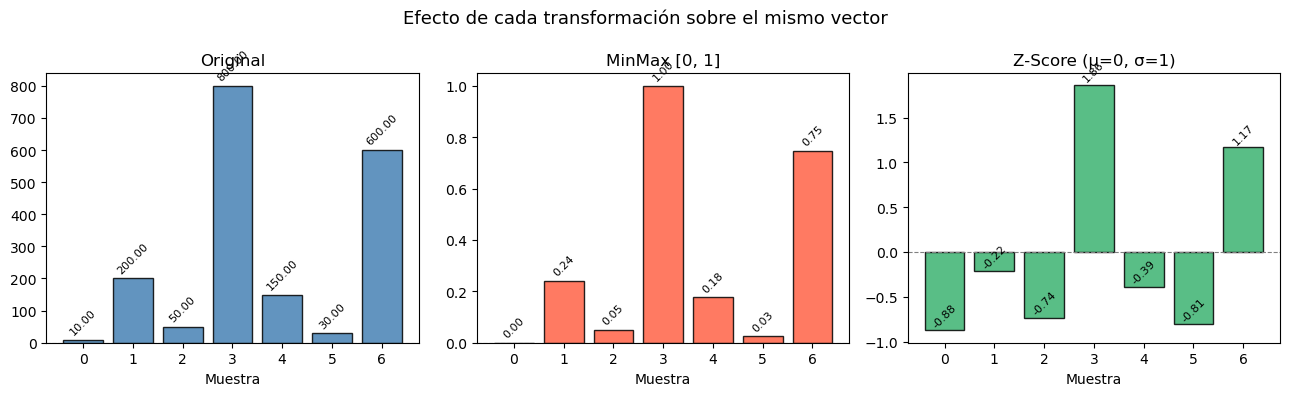

💡 Los valores relativos (orden, proporciones) se conservan en ambas técnicas.
   La diferencia está en cómo se reescalan: rango fijo vs. media=0.


In [3]:
# Visualización comparativa del ejemplo mínimo
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
fig.suptitle('Efecto de cada transformación sobre el mismo vector', fontsize=13)

datos = [x.ravel(), x_norm.ravel(), x_std.ravel()]
titulos = ['Original', 'MinMax [0, 1]', 'Z-Score (μ=0, σ=1)']
colores = ['steelblue', 'tomato', 'mediumseagreen']

for ax, d, t, c in zip(axes, datos, titulos, colores):
    ax.bar(range(len(d)), d, color=c, edgecolor='black', alpha=0.85)
    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')
    ax.set_title(t, fontsize=12)
    ax.set_xlabel('Muestra')
    for i, v in enumerate(d):
        ax.text(i, v + abs(d.max()) * 0.02, f'{v:.2f}',
                ha='center', fontsize=8, rotation=45)

plt.tight_layout()
plt.show()

print('💡 Los valores relativos (orden, proporciones) se conservan en ambas técnicas.')
print('   La diferencia está en cómo se reescalan: rango fijo vs. media=0.')

## ⚠️ Paso 3: El Problema de los Outliers

Una diferencia **crítica** entre ambas técnicas es su comportamiento ante valores atípicos (*outliers*).

Con MinMax, un solo valor extremo comprime todos los demás hacia 0, distorsionando la distribución. La Estandarización es más robusta porque usa la media y la desviación estándar.

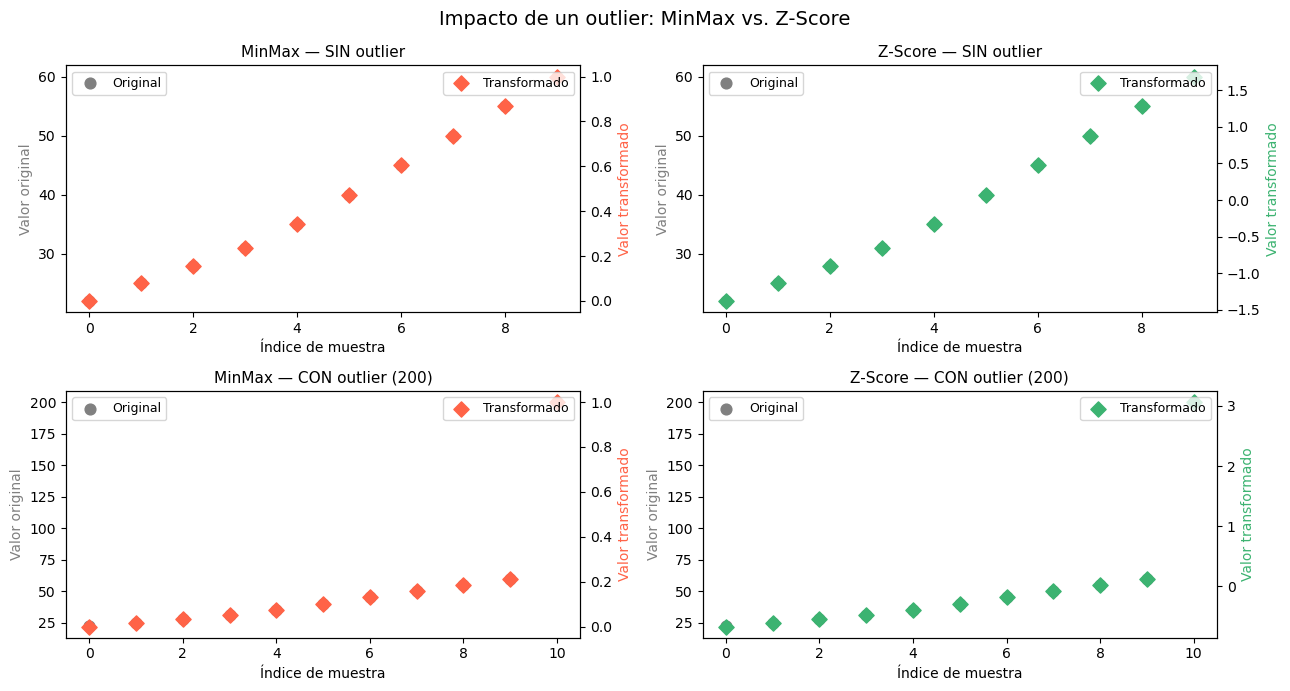

In [4]:
# Datos "normales": edades de personas entre 20 y 60 años
x_sin_outlier = np.array([22, 25, 28, 31, 35, 40, 45, 50, 55, 60]).reshape(-1, 1).astype(float)

# Los mismos datos, pero con UN outlier extremo (alguien de 200 años... ¡error de carga!)
x_con_outlier = np.append(x_sin_outlier, [[200]], axis=0).astype(float)

fig, axes = plt.subplots(2, 2, figsize=(13, 7))
fig.suptitle('Impacto de un outlier: MinMax vs. Z-Score', fontsize=14)

# Sin outlier
def graficar(ax, datos_orig, escalador, titulo, color):
    datos_esc = escalador.fit_transform(datos_orig)
    ax.scatter(range(len(datos_orig)), datos_orig, color='gray', s=60, label='Original', zorder=3)
    ax2 = ax.twinx()
    ax2.scatter(range(len(datos_esc)), datos_esc, color=color, s=60,
                marker='D', label='Transformado', zorder=3)
    ax.set_title(titulo, fontsize=11)
    ax.set_ylabel('Valor original', color='gray')
    ax2.set_ylabel('Valor transformado', color=color)
    ax.set_xlabel('Índice de muestra')
    ax.legend(loc='upper left', fontsize=9)
    ax2.legend(loc='upper right', fontsize=9)

graficar(axes[0,0], x_sin_outlier, MinMaxScaler(),  'MinMax — SIN outlier',  'tomato')
graficar(axes[0,1], x_sin_outlier, StandardScaler(), 'Z-Score — SIN outlier', 'mediumseagreen')
graficar(axes[1,0], x_con_outlier, MinMaxScaler(),  'MinMax — CON outlier (200)', 'tomato')
graficar(axes[1,1], x_con_outlier, StandardScaler(), 'Z-Score — CON outlier (200)', 'mediumseagreen')

plt.tight_layout()
plt.show()

In [5]:
# Mostramos numéricamente qué pasa con los valores originales (sin outlier) después de transformarlos
mm_sin = MinMaxScaler().fit_transform(x_sin_outlier).ravel()
mm_con = MinMaxScaler().fit_transform(x_con_outlier).ravel()[:-1]  # excluimos el outlier para comparar

zs_sin = StandardScaler().fit_transform(x_sin_outlier).ravel()
zs_con = StandardScaler().fit_transform(x_con_outlier).ravel()[:-1]

df_outlier = pd.DataFrame({
    'Original': x_sin_outlier.ravel().astype(int),
    'MinMax sin outlier': mm_sin.round(3),
    'MinMax con outlier': mm_con.round(3),
    'Z-Score sin outlier': zs_sin.round(3),
    'Z-Score con outlier': zs_con.round(3),
})

print('📋 Valores transformados de los datos originales (sin contar el outlier):')
print(df_outlier.to_string(index=False))

cambio_mm = (mm_con - mm_sin).mean()
cambio_zs = (zs_con - zs_sin).mean()
print(f'\n⚠️  Cambio promedio en MinMax al agregar outlier:  {cambio_mm:.4f}')
print(f'✅  Cambio promedio en Z-Score al agregar outlier: {cambio_zs:.4f}')
print('\n   MinMax redistribuye drásticamente todos los valores al introducir el outlier.')
print('   Z-Score muestra un impacto mucho menor sobre los puntos no atípicos.')

📋 Valores transformados de los datos originales (sin contar el outlier):
 Original  MinMax sin outlier  MinMax con outlier  Z-Score sin outlier  Z-Score con outlier
       22               0.000               0.000               -1.378               -0.665
       25               0.079               0.017               -1.136               -0.602
       28               0.158               0.034               -0.894               -0.539
       31               0.237               0.051               -0.653               -0.476
       35               0.342               0.073               -0.330               -0.392
       40               0.474               0.101                0.073               -0.288
       45               0.605               0.129                0.475               -0.183
       50               0.737               0.157                0.878               -0.078
       55               0.868               0.185                1.281                0.027
       

## 🍷 Paso 4: Efecto Visual sobre Distribuciones Reales — Dataset Wine

Usamos el dataset **Wine** (scikit-learn) para ver cómo cambian las distribuciones de features reales con cada técnica. Wine tiene 13 features en escalas muy distintas (Alcohol: 11–15, Malic acid: 0.7–5, Proline: 278–1680...).

In [6]:
# Cargar el dataset Wine
wine = datasets.load_wine()
df_wine = pd.DataFrame(wine.data, columns=wine.feature_names)

print('🍷 Dataset Wine:')
print(f'  {df_wine.shape[0]} muestras, {df_wine.shape[1]} features')
print('\n📊 Estadísticas de las primeras 4 features (escalas muy distintas):')
print(df_wine.iloc[:, :4].describe().round(2))

🍷 Dataset Wine:
  178 muestras, 13 features

📊 Estadísticas de las primeras 4 features (escalas muy distintas):
       alcohol  malic_acid     ash  alcalinity_of_ash
count   178.00      178.00  178.00             178.00
mean     13.00        2.34    2.37              19.49
std       0.81        1.12    0.27               3.34
min      11.03        0.74    1.36              10.60
25%      12.36        1.60    2.21              17.20
50%      13.05        1.87    2.36              19.50
75%      13.68        3.08    2.56              21.50
max      14.83        5.80    3.23              30.00


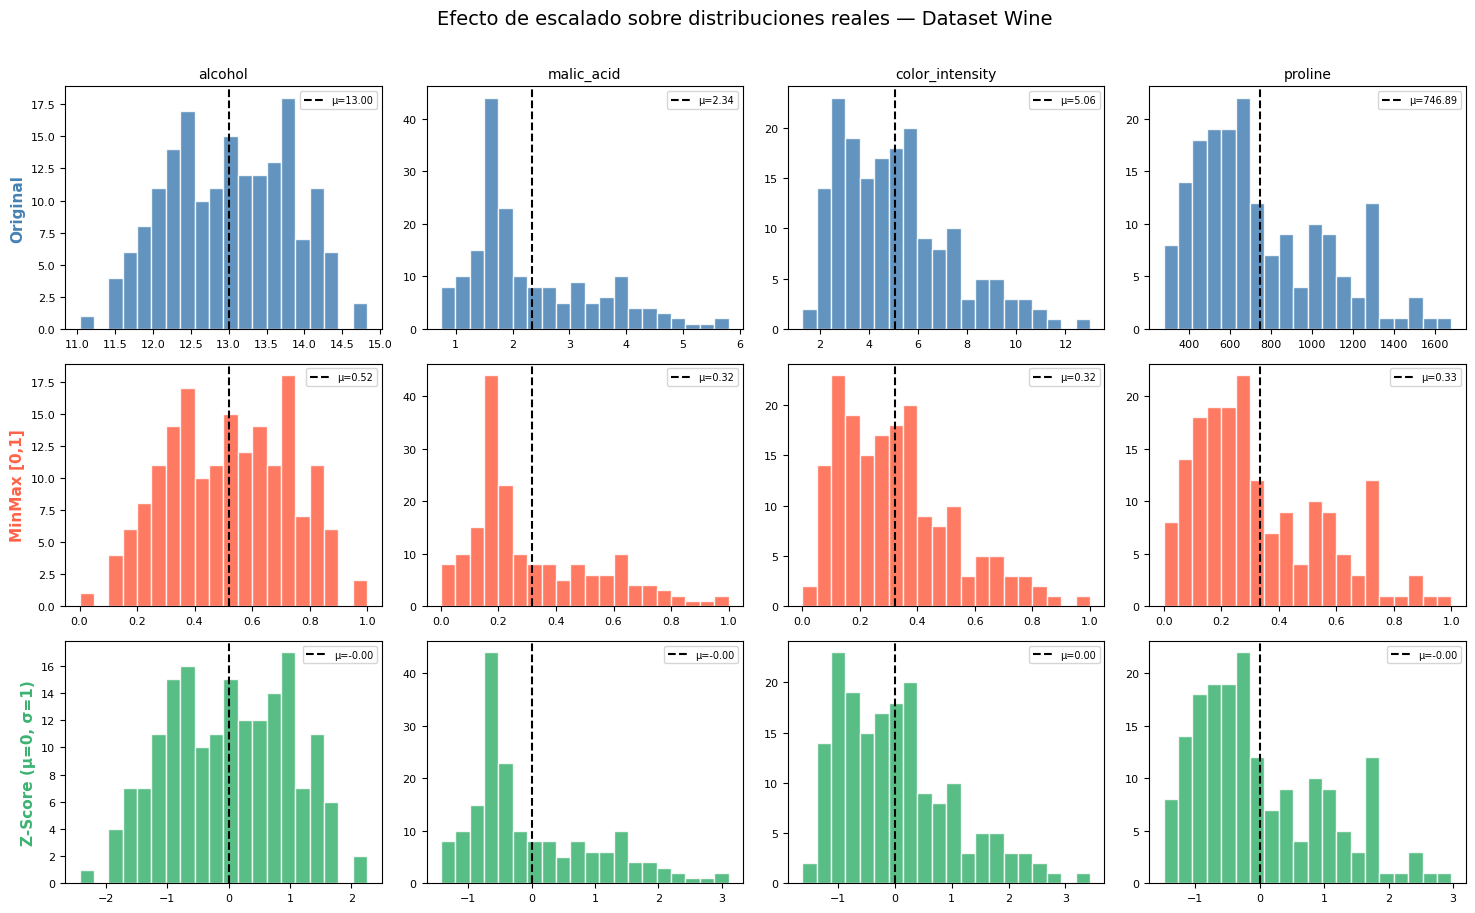

💡 La forma de la distribución se preserva en ambas técnicas.
   MinMax lleva todas las distribuciones al rango [0,1].
   Z-Score centra todas las distribuciones en 0, con std=1.


In [7]:
# Aplicar ambas transformaciones
X_wine = df_wine.values

X_norm = MinMaxScaler().fit_transform(X_wine)
X_std  = StandardScaler().fit_transform(X_wine)

# Elegimos 4 features representativas para graficar
features_idx = [0, 1, 9, 12]   # alcohol, malic_acid, color_intensity, proline
feature_names_sel = [wine.feature_names[i] for i in features_idx]

fig, axes = plt.subplots(3, 4, figsize=(15, 9))
fig.suptitle('Efecto de escalado sobre distribuciones reales — Dataset Wine',
             fontsize=14, y=1.01)

titulos_fila = ['Original', 'MinMax [0,1]', 'Z-Score (μ=0, σ=1)']
datos_filas  = [X_wine, X_norm, X_std]
colores_fila = ['steelblue', 'tomato', 'mediumseagreen']

for row, (datos, titulo_fila, color) in enumerate(zip(datos_filas, titulos_fila, colores_fila)):
    for col, (feat_idx, feat_name) in enumerate(zip(features_idx, feature_names_sel)):
        ax = axes[row, col]
        ax.hist(datos[:, feat_idx], bins=20, color=color, edgecolor='white', alpha=0.85)
        if col == 0:
            ax.set_ylabel(titulo_fila, fontsize=11, fontweight='bold', color=color)
        if row == 0:
            ax.set_title(feat_name, fontsize=10)
        mu = datos[:, feat_idx].mean()
        ax.axvline(mu, color='black', linewidth=1.5, linestyle='--',
                   label=f'μ={mu:.2f}')
        ax.legend(fontsize=7, loc='upper right')
        ax.tick_params(labelsize=8)

plt.tight_layout()
plt.show()

print('💡 La forma de la distribución se preserva en ambas técnicas.')
print('   MinMax lleva todas las distribuciones al rango [0,1].')
print('   Z-Score centra todas las distribuciones en 0, con std=1.')

## 📦 Paso 5: Boxplots — Visualización Completa de Todas las Features

Los **boxplots** permiten ver la escala de todas las features de una vez, mostrando claramente cómo el escalado las uniformiza.

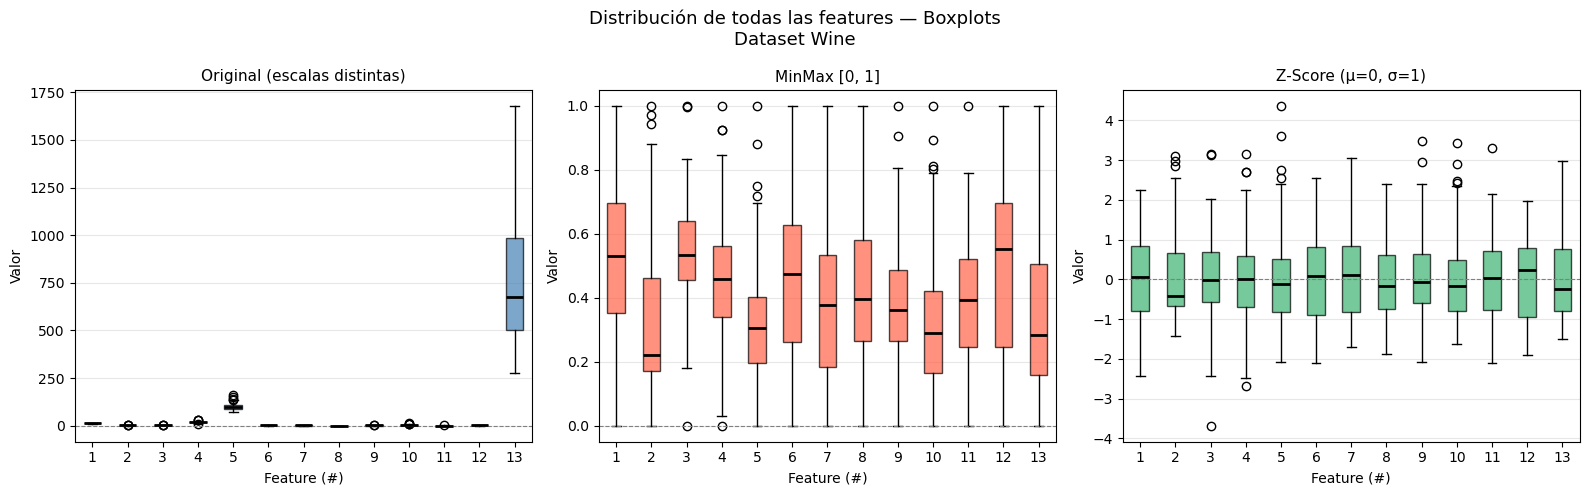

⚠️  Sin escalar: feature 13 (Proline, ~700-1700) domina visualmente.
   Con MinMax: todas las features caben entre 0 y 1.
   Con Z-Score: todas las features se centran en 0 con dispersión comparable.


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Distribución de todas las features — Boxplots\nDataset Wine', fontsize=13)

configs = [
    (X_wine, 'Original (escalas distintas)', 'steelblue'),
    (X_norm, 'MinMax [0, 1]',                'tomato'),
    (X_std,  'Z-Score (μ=0, σ=1)',           'mediumseagreen'),
]

for ax, (datos, titulo, color) in zip(axes, configs):
    bp = ax.boxplot(datos, patch_artist=True,
                    medianprops={'color': 'black', 'linewidth': 2},
                    boxprops={'facecolor': color, 'alpha': 0.7})
    ax.set_title(titulo, fontsize=11)
    ax.set_xlabel('Feature (#)')
    ax.set_ylabel('Valor')
    ax.grid(True, axis='y', alpha=0.3)
    ax.axhline(0, color='gray', linewidth=0.8, linestyle='--')

plt.tight_layout()
plt.show()

print('⚠️  Sin escalar: feature 13 (Proline, ~700-1700) domina visualmente.')
print('   Con MinMax: todas las features caben entre 0 y 1.')
print('   Con Z-Score: todas las features se centran en 0 con dispersión comparable.')

## 🗺️ Paso 6: Impacto en KNN — ¿Es necesario normalizar?

KNN basa sus predicciones en **distancias**. Sin escalado, las features con valores grandes dominan la distancia euclidiana y distorsionan los resultados. Veamos el impacto real en la Accuracy.

In [9]:
X_wine_arr = df_wine.values
y_wine = wine.target

# Configuraciones a comparar
configuraciones = {
    'Sin escalar':   X_wine_arr,
    'MinMax [0,1]':  MinMaxScaler().fit_transform(X_wine_arr),
    'Z-Score':       StandardScaler().fit_transform(X_wine_arr),
}

k_values = [1, 3, 5, 7, 9, 11]
resultados_knn = {}

for nombre, X_esc in configuraciones.items():
    scores_k = []
    for k in k_values:
        knn = KNeighborsClassifier(n_neighbors=k)
        score = cross_val_score(knn, X_esc, y_wine, cv=5, scoring='accuracy').mean()
        scores_k.append(score)
    resultados_knn[nombre] = scores_k

# Tabla resumen
df_knn = pd.DataFrame(resultados_knn, index=[f'k={k}' for k in k_values])
print('📊 Accuracy (CV=5) de KNN en Dataset Wine según escalado:')
print((df_knn * 100).round(1).to_string())
print('\n  (valores en %)')

📊 Accuracy (CV=5) de KNN en Dataset Wine según escalado:
      Sin escalar  MinMax [0,1]  Z-Score
k=1          72.5          94.4     95.0
k=3          70.3          95.0     94.4
k=5          69.1          95.5     95.5
k=7          68.1          97.8     96.7
k=9          70.3          95.0     95.0
k=11         68.0          96.1     95.5

  (valores en %)


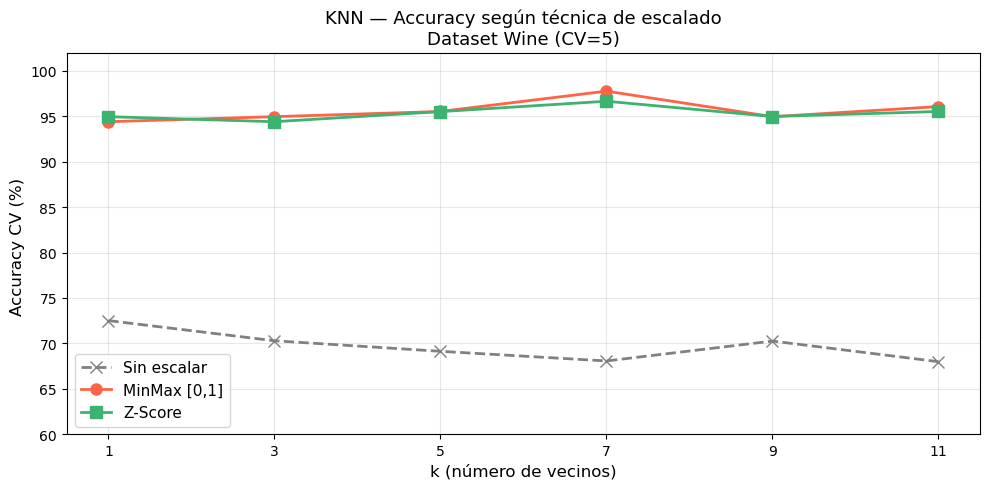


🏆 Mejor Accuracy por configuración:
  Sin escalar         : 72.5%  (k=1)
  MinMax [0,1]        : 97.8%  (k=7)
  Z-Score             : 96.7%  (k=7)


In [10]:
# Gráfico de comparación
fig, ax = plt.subplots(figsize=(10, 5))

colores_conf = ['gray', 'tomato', 'mediumseagreen']
marcadores   = ['x', 'o', 's']
estilos      = ['--', '-', '-']

for (nombre, scores), color, marker, estilo in zip(
        resultados_knn.items(), colores_conf, marcadores, estilos):
    ax.plot(k_values, [s * 100 for s in scores],
            marker=marker, color=color, linewidth=2,
            linestyle=estilo, markersize=8, label=nombre)

ax.set_xlabel('k (número de vecinos)', fontsize=12)
ax.set_ylabel('Accuracy CV (%) ', fontsize=12)
ax.set_title('KNN — Accuracy según técnica de escalado\nDataset Wine (CV=5)', fontsize=13)
ax.legend(fontsize=11)
ax.set_xticks(k_values)
ax.grid(True, alpha=0.3)
ax.set_ylim(60, 102)
plt.tight_layout()
plt.show()

# Mejor resultado de cada configuración
print('\n🏆 Mejor Accuracy por configuración:')
for nombre, scores in resultados_knn.items():
    mejor = max(scores)
    mejor_k = k_values[scores.index(mejor)]
    print(f'  {nombre:20s}: {mejor*100:.1f}%  (k={mejor_k})')

## 📐 Paso 7: Impacto en SVM — Estandarización es clave

SVM construye hiperplanos en el espacio de features y maximiza el margen. Sin escalar, las features con valores grandes sesgan la posición del hiperplano. La teoría indica que SVM se beneficia especialmente de la **Estandarización**, no de la normalización.

Verifiquemos esto empíricamente con el dataset **Breast Cancer**.

In [11]:
cancer = datasets.load_breast_cancer()
X_cancer, y_cancer = cancer.data, cancer.target

configuraciones_svm = {
    'Sin escalar':   X_cancer,
    'MinMax [0,1]':  MinMaxScaler().fit_transform(X_cancer),
    'Z-Score':       StandardScaler().fit_transform(X_cancer),
}

kernels = ['rbf', 'linear', 'poly']

print('📊 Accuracy (CV=5) de SVM en Breast Cancer según escalado:')
print(f"  {'Kernel':<10} {'Sin escalar':>14} {'MinMax [0,1]':>14} {'Z-Score':>10}")
print('  ' + '-' * 52)

resultados_svm = {}
for kernel in kernels:
    scores_por_esc = {}
    for nombre, X_esc in configuraciones_svm.items():
        clf = SVC(kernel=kernel, random_state=SEED)
        score = cross_val_score(clf, X_esc, y_cancer, cv=5, scoring='accuracy').mean()
        scores_por_esc[nombre] = score
    resultados_svm[kernel] = scores_por_esc
    vals = list(scores_por_esc.values())
    print(f"  {kernel:<10} {vals[0]*100:>13.1f}%  {vals[1]*100:>12.1f}%  {vals[2]*100:>8.1f}%")

📊 Accuracy (CV=5) de SVM en Breast Cancer según escalado:
  Kernel        Sin escalar   MinMax [0,1]    Z-Score
  ----------------------------------------------------
  rbf                 91.2%          97.4%      97.4%
  linear              94.6%          97.5%      97.0%
  poly                90.9%          97.4%      89.8%


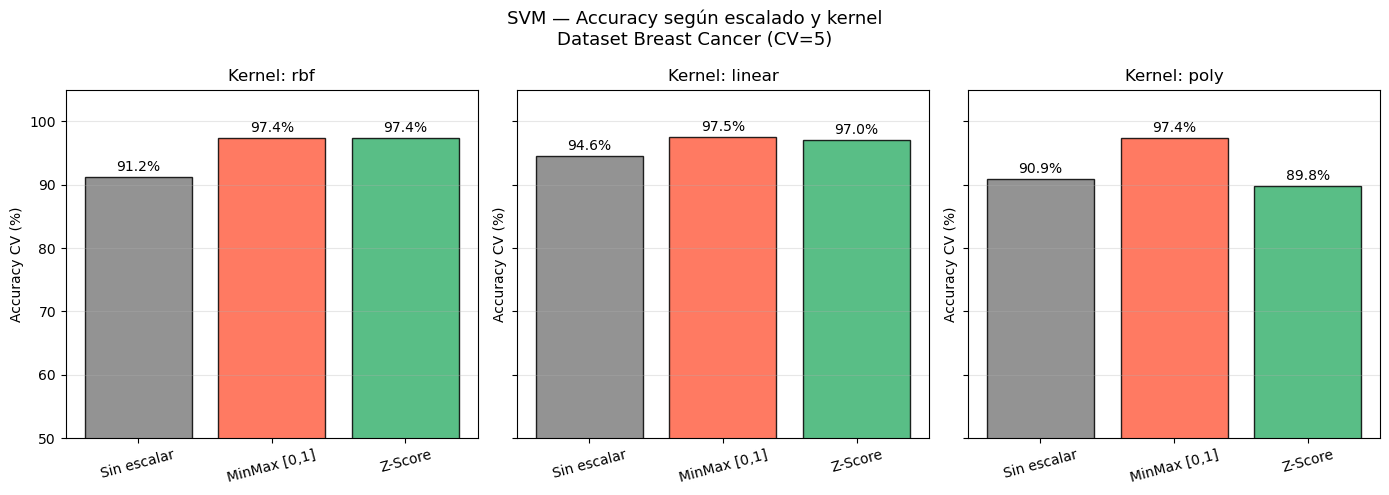


💡 Observaciones:
   - El kernel RBF es altamente sensible a la escala.
   - Z-Score tiende a igualar o superar a MinMax para SVM.
   - El kernel lineal es más robusto, pero aún se beneficia del escalado.


In [12]:
# Visualización por kernel
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)
fig.suptitle('SVM — Accuracy según escalado y kernel\nDataset Breast Cancer (CV=5)', fontsize=13)

nombres_esc = list(configuraciones_svm.keys())
colores_esc = ['gray', 'tomato', 'mediumseagreen']

for ax, kernel in zip(axes, kernels):
    scores = [resultados_svm[kernel][n] * 100 for n in nombres_esc]
    bars = ax.bar(nombres_esc, scores, color=colores_esc,
                  edgecolor='black', alpha=0.85)
    ax.set_title(f'Kernel: {kernel}', fontsize=12)
    ax.set_ylabel('Accuracy CV (%)')
    ax.set_ylim(50, 105)
    ax.tick_params(axis='x', rotation=15)
    ax.grid(True, axis='y', alpha=0.3)
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.5,
                f'{bar.get_height():.1f}%', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print('\n💡 Observaciones:')
print('   - El kernel RBF es altamente sensible a la escala.')
print('   - Z-Score tiende a igualar o superar a MinMax para SVM.')
print('   - El kernel lineal es más robusto, pero aún se beneficia del escalado.')

## 🚨 Paso 8: Data Leakage — El Error Más Común con el Escalado

> **⚠️ Error crítico muy frecuente:** escalar los datos *antes* de dividir en train/test.

Si ajustamos el `MinMaxScaler` sobre **todo el dataset** (incluido el conjunto de test), estamos usando información del futuro para transformar los datos de entrenamiento. Esto es **data leakage** y produce métricas artificialmente optimistas.

**La forma correcta:** ajustar (`fit`) el scaler **solo** en el conjunto de entrenamiento y aplicarlo (`transform`) tanto a train como a test.

In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X_cancer, y_cancer, test_size=0.2, random_state=SEED)

# ❌ MAL: fit sobre todo el dataset (data leakage)
scaler_mal = StandardScaler()
scaler_mal.fit(X_cancer)                    # usa información de X_test
X_train_mal = scaler_mal.transform(X_train)
X_test_mal  = scaler_mal.transform(X_test)

# ✅ BIEN: fit solo sobre X_train
scaler_bien = StandardScaler()
scaler_bien.fit(X_train)                    # solo usa X_train
X_train_bien = scaler_bien.transform(X_train)
X_test_bien  = scaler_bien.transform(X_test)

# ✅✅ MEJOR: usar Pipeline (automatiza el proceso correctamente en CV)
pipe = Pipeline([('scaler', StandardScaler()), ('svm', SVC(kernel='rbf', random_state=SEED))])

svm_mal  = SVC(kernel='rbf', random_state=SEED).fit(X_train_mal,  y_train)
svm_bien = SVC(kernel='rbf', random_state=SEED).fit(X_train_bien, y_train)
pipe.fit(X_train, y_train)

acc_mal  = svm_mal.score(X_test_mal,  y_test)
acc_bien = svm_bien.score(X_test_bien, y_test)
acc_pipe = pipe.score(X_test, y_test)

print('⚠️  Comparación: impacto del Data Leakage en el escalado')
print('=' * 52)
print(f'  ❌ fit sobre todo el dataset (leakage): {acc_mal*100:.2f}%')
print(f'  ✅ fit solo en X_train (correcto):       {acc_bien*100:.2f}%')
print(f'  ✅ Pipeline (automático y seguro):       {acc_pipe*100:.2f}%')
print('=' * 52)
print('\n💡 El Pipeline es la forma más segura: garantiza que el scaler')
print('   se ajuste solo con datos de entrenamiento, incluso en CV.')

⚠️  Comparación: impacto del Data Leakage en el escalado
  ❌ fit sobre todo el dataset (leakage): 97.37%
  ✅ fit solo en X_train (correcto):       98.25%
  ✅ Pipeline (automático y seguro):       98.25%

💡 El Pipeline es la forma más segura: garantiza que el scaler
   se ajuste solo con datos de entrenamiento, incluso en CV.


## 🗺️ Paso 9: Guía Práctica — ¿Cuándo usar cada técnica?

Resumimos las reglas prácticas derivadas tanto de la teoría como de los experimentos anteriores:

In [14]:
guia = {
    'Algoritmo / Situación': [
        'K-Nearest Neighbors (KNN)',
        'Support Vector Machines (SVM)',
        'Regresión Logística',
        'Árbol de Decisión / Random Forest',
        'Redes Neuronales',
        'PCA / Reducción dimensionalidad',
        'Hay outliers significativos',
        'Distribución muy sesgada (skewed)',
        'Se necesita interpretabilidad',
    ],
    'Normalización (MinMax)': [
        '✅ Recomendada',
        '⚠️ Funciona, pero Z-Score suele ser mejor',
        '⚠️ Aceptable',
        '🔵 No necesario (invariante a escala)',
        '✅ Recomendada (entrada en [0,1])',
        '❌ No recomendada',
        '❌ Mala elección (outlier comprime todo)',
        '⚠️ Útil si la skewness no es extrema',
        '✅ Coeficientes en [0,1] son interpretables',
    ],
    'Estandarización (Z-Score)': [
        '✅ También funciona bien',
        '✅ Recomendada',
        '✅ Recomendada',
        '🔵 No necesario (invariante a escala)',
        '✅ Recomendada (gradientes estables)',
        '✅ Recomendada (respeta varianza)',
        '✅ Más robusta que MinMax',
        '⚠️ Mejor que MinMax, pero log puede ser mejor',
        '✅ Coeficientes en σ son interpretables',
    ],
}

df_guia = pd.DataFrame(guia)
print('📋 Guía de selección: Normalización vs. Estandarización')
print(df_guia.to_string(index=False))

📋 Guía de selección: Normalización vs. Estandarización
            Algoritmo / Situación                     Normalización (MinMax)                     Estandarización (Z-Score)
        K-Nearest Neighbors (KNN)                              ✅ Recomendada                       ✅ También funciona bien
    Support Vector Machines (SVM)  ⚠️ Funciona, pero Z-Score suele ser mejor                                 ✅ Recomendada
              Regresión Logística                               ⚠️ Aceptable                                 ✅ Recomendada
Árbol de Decisión / Random Forest       🔵 No necesario (invariante a escala)          🔵 No necesario (invariante a escala)
                 Redes Neuronales           ✅ Recomendada (entrada en [0,1])           ✅ Recomendada (gradientes estables)
  PCA / Reducción dimensionalidad                           ❌ No recomendada              ✅ Recomendada (respeta varianza)
      Hay outliers significativos    ❌ Mala elección (outlier comprime todo)        

## 🎓 Resumen y Conclusiones

En este notebook exploramos las diferencias entre las dos técnicas de escalado de features más usadas:

| | MinMax (Normalización) | Z-Score (Estandarización) |
|---|---|---|
| **Fórmula** | $(x - x_{min}) / (x_{max} - x_{min})$ | $(x - \mu) / \sigma$ |
| **Resultado** | Rango fijo [0, 1] | Media=0, Std=1 |
| **Outliers** | ❌ Muy sensible | ✅ Más robusta |
| **KNN** | ✅ Funciona bien | ✅ Funciona bien |
| **SVM** | ⚠️ Subóptimo | ✅ Preferida |
| **Redes Neuronales** | ✅ Ideal para [0,1] | ✅ También funciona |
| **Árboles / RF** | 🔵 Innecesario | 🔵 Innecesario |

### ⚠️ Regla crítica: no hacer Data Leakage

Siempre ajustar el scaler **solo** sobre los datos de entrenamiento. Usar **Pipelines** para garantizarlo automáticamente, especialmente en validación cruzada.

### 🚀 ¿Qué sigue?

- 🔢 **Reducción de dimensionalidad (PCA)**: donde la estandarización previa es obligatoria
- 🧹 **Manejo de outliers**: `RobustScaler` de scikit-learn como alternativa aún más robusta
- 🔠 **Variables categóricas**: `OneHotEncoder` para variables nominales sin orden

> 📚 **Referencias:**
> - Shaibu, S. (2024). [Normalization vs. Standardization: How to Know the Difference](https://www.datacamp.com/tutorial/normalization-vs-standardization). *DataCamp*.
> - [scikit-learn — StandardScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)
> - [scikit-learn — MinMaxScaler](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.MinMaxScaler.html)
> - [scikit-learn — Preprocessing data](https://scikit-learn.org/stable/modules/preprocessing.html)

---

© 2026 Cátedra Inteligencia Artificial — Lic. en Sistemas

Este notebook se distribuye bajo licencia [CC BY-SA 4.0](https://creativecommons.org/licenses/by-sa/4.0/).